# Task 05 - Neural Style Transfer
Prodigy InfoTech internship

Blending the style of a painting onto a normal photo using a pretrained VGG19. Optimizing the output image directly against content + style loss (Gatys et al. method). Use GPU runtime.

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import PIL.Image

print(tf.__version__, tf.config.list_physical_devices('GPU'))

2.20.0 [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### Load images
Using sample content/style images for now, swap the paths below for your own if you want.

In [2]:
content_path = tf.keras.utils.get_file('content.jpg', 'https://storage.googleapis.com/download.tensorflow.org/example_images/YellowLabradorLooking_new.jpg')
style_path = tf.keras.utils.get_file('style.jpg', 'https://storage.googleapis.com/download.tensorflow.org/example_images/Vassily_Kandinsky%2C_1913_-_Composition_7.jpg')

def load_img(path, max_dim=512):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3)
    img = tf.image.convert_image_dtype(img, tf.float32)

    shape = tf.cast(tf.shape(img)[:-1], tf.float32)
    scale = max_dim / max(shape)
    new_shape = tf.cast(shape * scale, tf.int32)

    img = tf.image.resize(img, new_shape)
    return img[tf.newaxis, :]

content_image = load_img(content_path)
style_image = load_img(style_path)

83281/83281 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
195196/195196 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


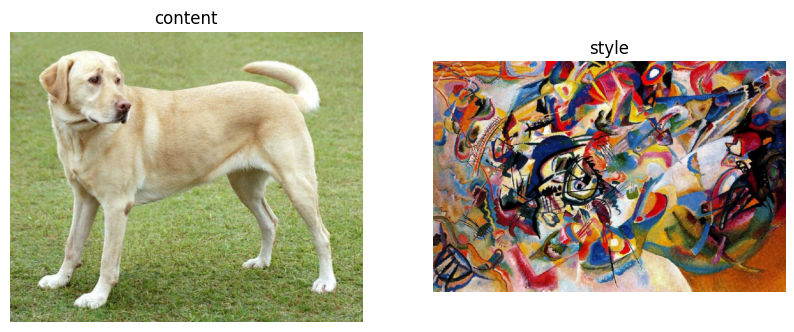

In [3]:
def imshow(image, title=None):
    if len(image.shape) > 3:
        image = tf.squeeze(image, axis=0)
    plt.imshow(image)
    if title: plt.title(title)
    plt.axis('off')

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); imshow(content_image, 'content')
plt.subplot(1, 2, 2); imshow(style_image, 'style')

### VGG19 as feature extractor
Only using it to pull out intermediate conv activations, not for classification. Early layers pick up style (textures/colors), a deeper layer captures content (overall structure).

In [4]:
content_layers = ['block5_conv2']
style_layers = ['block1_conv1', 'block2_conv1', 'block3_conv1', 'block4_conv1', 'block5_conv1']
num_content_layers = len(content_layers)
num_style_layers = len(style_layers)

def vgg_layers(layer_names):
    vgg = tf.keras.applications.VGG19(include_top=False, weights='imagenet')
    vgg.trainable = False
    outputs = [vgg.get_layer(name).output for name in layer_names]
    return tf.keras.Model([vgg.input], outputs)

In [5]:
def gram_matrix(input_tensor):
    result = tf.linalg.einsum('bijc,bijd->bcd', input_tensor, input_tensor)
    input_shape = tf.shape(input_tensor)
    num_locations = tf.cast(input_shape[1]*input_shape[2], tf.float32)
    return result / num_locations

class StyleContentModel(tf.keras.models.Model):
    def __init__(self, style_layers, content_layers):
        super().__init__()
        self.vgg = vgg_layers(style_layers + content_layers)
        self.style_layers = style_layers
        self.content_layers = content_layers
        self.num_style_layers = len(style_layers)
        self.vgg.trainable = False

    def call(self, inputs):
        inputs = inputs * 255.0
        preprocessed_input = tf.keras.applications.vgg19.preprocess_input(inputs)
        outputs = self.vgg(preprocessed_input)
        style_outputs, content_outputs = (outputs[:self.num_style_layers], outputs[self.num_style_layers:])

        style_outputs = [gram_matrix(o) for o in style_outputs]

        content_dict = {name: value for name, value in zip(self.content_layers, content_outputs)}
        style_dict = {name: value for name, value in zip(self.style_layers, style_outputs)}

        return {'content': content_dict, 'style': style_dict}

extractor = StyleContentModel(style_layers, content_layers)
style_targets = extractor(style_image)['style']
content_targets = extractor(content_image)['content']

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


### Losses + training step
Style loss - mse between gram matrices. Content loss - mse between raw feature maps. Added total variation loss too so the output doesn't come out too noisy.

In [6]:
style_weight = 1e-2
content_weight = 1e4
total_variation_weight = 30

def style_content_loss(outputs):
    style_outputs = outputs['style']
    content_outputs = outputs['content']

    style_loss = tf.add_n([tf.reduce_mean((style_outputs[name]-style_targets[name])**2) for name in style_outputs.keys()])
    style_loss *= style_weight / num_style_layers

    content_loss = tf.add_n([tf.reduce_mean((content_outputs[name]-content_targets[name])**2) for name in content_outputs.keys()])
    content_loss *= content_weight / num_content_layers

    return style_loss + content_loss

def clip_0_1(image):
    return tf.clip_by_value(image, 0.0, 1.0)

image = tf.Variable(content_image)  # start from content image, optimize from there
opt = tf.keras.optimizers.Adam(learning_rate=0.02, beta_1=0.99, epsilon=1e-1)

@tf.function
def train_step(image):
    with tf.GradientTape() as tape:
        outputs = extractor(image)
        loss = style_content_loss(outputs)
        loss += total_variation_weight * tf.image.total_variation(image)

    grad = tape.gradient(loss, image)
    opt.apply_gradients([(grad, image)])
    image.assign(clip_0_1(image))

### Training
Real Gatys-style optimization usually needs a couple thousand steps to look good. Running 10 epochs x 100 steps here, image updates every epoch so you can see it evolve.

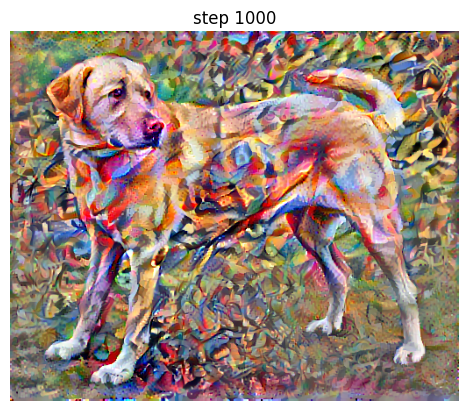

total time: 91.2s


In [7]:
import time
start = time.time()

epochs, steps_per_epoch = 10, 100
step = 0
for n in range(epochs):
    for m in range(steps_per_epoch):
        step += 1
        train_step(image)
        print('.', end='', flush=True)
    from IPython import display
    display.clear_output(wait=True)
    imshow(image.read_value())
    plt.title(f"step {step}")
    plt.show()

print(f'total time: {time.time()-start:.1f}s')

### Final comparison

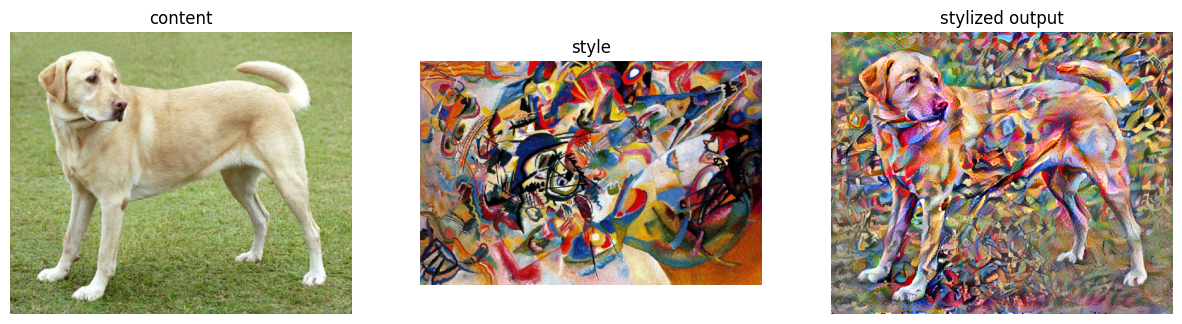

In [8]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1); imshow(content_image, 'content')
plt.subplot(1, 3, 2); imshow(style_image, 'style')
plt.subplot(1, 3, 3); imshow(image.read_value(), 'stylized output')

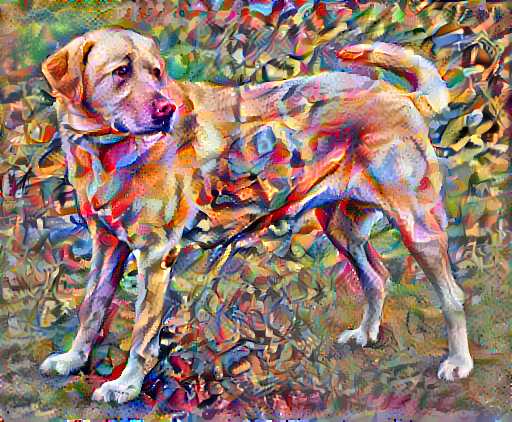

In [9]:
def tensor_to_image(tensor):
    tensor = tensor*255
    tensor = np.array(tensor, dtype=np.uint8)
    if np.ndim(tensor) > 3:
        tensor = tensor[0]
    return PIL.Image.fromarray(tensor)

result = tensor_to_image(image)
result.save('stylized_output.png')
result